<div style='background: linear-gradient(135deg, #667eea 0%, #b1d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Modelisation</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

# Imports and config

In [453]:
import sys
from pathlib import Path

root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.config import paths
from src.utils.country import apply_ne_mapping

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from time import time

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              confusion_matrix)
import geopandas as gpd
import matplotlib.patches as mpatches
import joblib

SEED    = 42
K_RANGE = range(2, 9)
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F18F01', '#C490D1', '#A23B72', '#F5E6CA']
N_RUNS  = 100

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# Section 1 : Chargement des données

Les deux fichiers chargés ici :

final_main_data.csv regroupe 8 variables issues du dataset original Country-data.csv, après transformation logarithmique des 6 variables fortement asymétriques (|skew| > 1) et suppression de la redondance income/gdpp en faveur de gdpp dont le coefficient de variation est supérieur (17.6 % contre 13.5 %).

final_enriched_data.csv regroupe 14 variables issues de l'enrichissement multi-source : données WDI de la Banque Mondiale, indicateurs sociaux , et Fragile States Index 2015 . Les valeurs manquantes ont été imputées par KNN , et les variables asymétriques transformées en log.

In [417]:
df_raw    = pd.read_csv(paths.DATA_DIR / 'final' / 'final_main_data.csv')
df_enrich = pd.read_csv(paths.DATA_DIR / 'final' / 'final_enriched_data.csv')

id_col_r   = 'country'
num_cols_r = df_raw.select_dtypes(include=np.number).columns.tolist()

id_cols_e  = ['country', 'iso_code']
num_cols_e = [c for c in df_enrich.columns if c not in id_cols_e]

print('Dataset classique  :', df_raw.shape)
print('Variables          :', num_cols_r)
print()
print('Dataset enrichi    :', df_enrich.shape)
print('Variables          :', num_cols_e)

Dataset classique  : (167, 9)
Variables          : ['life_expec', 'child_mort_log', 'total_fer', 'gdpp_log', 'health', 'inflation_log', 'exports_log', 'imports_log']

Dataset enrichi    : (167, 16)
Variables          : ['physicians_per_1000', 'hiv_prevalence_log', 'life_expec', 'child_mort_log', 'vaccination_dpt_log', 'gdpp_log', 'inflation_log', 'social_undernourishment_log', 'social_poverty_2_15_log', 'social_schooling_log', 'security_apparatus', 'group_grievance', 'refugees_idps', 'external_intervention']


### Chargement du fond de carte Natural Earth

In [ ]:
_ne_cache = paths.ROOT_DIR / 'scratch' / '_ne_world.gpkg'
_ne_url   = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'
if not _ne_cache.exists():
    world = gpd.read_file(_ne_url)
    _ne_cache.parent.mkdir(parents=True, exist_ok=True)
    world.to_file(str(_ne_cache), driver='GPKG')
    print('Fond de carte téléchargé et mis en cache.')
else:
    world = gpd.read_file(str(_ne_cache))
    print('Fond de carte chargé depuis le cache.')



Fond de carte chargé depuis le cache.


> Noter que les petits pays environ 10 seront afiché comme non couvert sur les cartes car non inclu dans ,'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

---
# Partie I : Dataset classique

## Mise à l'échelle

La normalisation est nécessaire car les 8 variables ont des unités et des dynamiques très différentes . Sans normalisation, les variables à grande amplitude écraseront les distances euclidiennes.

Le choix du `RobustScaler` (centrage sur la médiane, réduction par l'écart interquartile) plutôt que le `StandardScaler` (centrage sur la moyenne) est motivé par les outliers légitimes documentés en P1 : des pays comme le Luxembourg (exports_log extrême) ou le Niger (total_fer extrême) ne doivent pas distordre l'échelle. Le RobustScaler les préserve sans les amplifier.

In [454]:
scaler_r = RobustScaler()
X_raw    = scaler_r.fit_transform(df_raw[num_cols_r])
print(f'Matrice : {X_raw.shape[0]} pays × {X_raw.shape[1]} variables')

Matrice : 167 pays × 8 variables


## Analyse en Composantes Principales

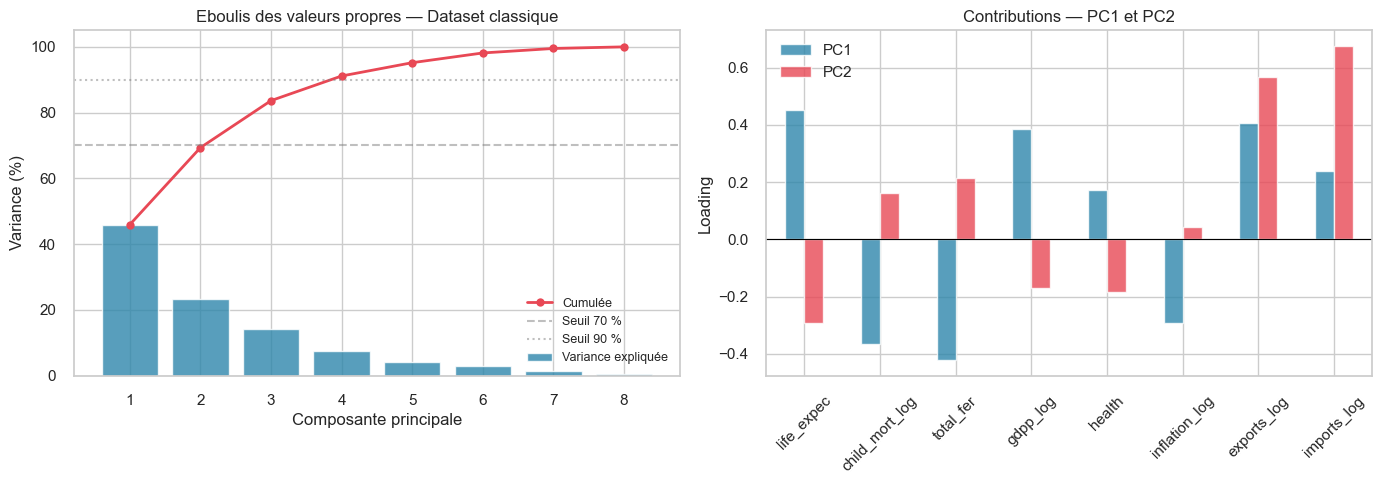

PC1 : 46.0%  |  PC2 : 23.4%  |  PC1+PC2 : 69.4%
PC1+PC2+PC3 : 83.6%
90 % de variance atteint à PC4


In [420]:
pca_r = PCA(random_state=SEED)
pca_r.fit(X_raw)

var_exp = pca_r.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color='#2E86AB', alpha=0.8, label='Variance expliquée')
axes[0].plot(range(1, len(cum_var)+1), cum_var * 100, 'o-', color='#E84855', linewidth=2, label='Cumulée')
axes[0].axhline(70, color='gray', linestyle='--', alpha=0.5, label='Seuil 70 %')
axes[0].axhline(90, color='gray', linestyle=':', alpha=0.5, label='Seuil 90 %')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Eboulis des valeurs propres — Dataset classique')
axes[0].legend(fontsize=9)

loadings = pd.DataFrame(pca_r.components_[:2].T, index=num_cols_r, columns=['PC1','PC2'])
loadings.plot(kind='bar', ax=axes[1], color=['#2E86AB','#E84855'], alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Contributions — PC1 et PC2')
axes[1].set_ylabel('Loading')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'PC1 : {var_exp[0]*100:.1f}%  |  PC2 : {var_exp[1]*100:.1f}%  |  PC1+PC2 : {cum_var[1]*100:.1f}%')
print(f'PC1+PC2+PC3 : {cum_var[2]*100:.1f}%')
print(f'90 % de variance atteint à PC{(cum_var>=0.90).argmax()+1}')

PC1 explique 46. % de la variance totale et oppose les indicateurs de développement humain : life_expec et gdpp_log ont des loadings fortement négatifs (pays développés , scores PC1 négatifs), tandis que child_mort_log et total_fer ont des loadings positifs (pays en difficulté , scores PC1 élevés). C'est un axe synthétique de développement global.

PC2 (23.4 %) capture une dimension orthogonale liée aux échanges commerciaux (exports_log, imports_log) et à l'inflation. Les deux premières composantes restituent 69.4 % de la variance — suffisant pour une visualisation indicative mais insuffisant pour remplacer l'espace complet dans le clustering.

##  Sélection du nombre de clusters k

Quatre métriques sont calculées simultanément sur k ∈ [2, 8] pour croiser les signaux :

L'inertie (somme des distances quadratiques au centroïde) décroît monotonement  on cherche le coude. Le score de silhouette mesure la cohésion intra-cluster et la séparation inter-cluster (un score > 0 indique que les points sont plus proches de leur propre cluster que du voisin). L'indice Calinski-Harabasz (CH) rapporte la dispersion inter sur la dispersion intra , maximiser. L'indice Davies-Bouldin (DB) mesure la similarité entre chaque cluster et son voisin le plus proche , minimiser.

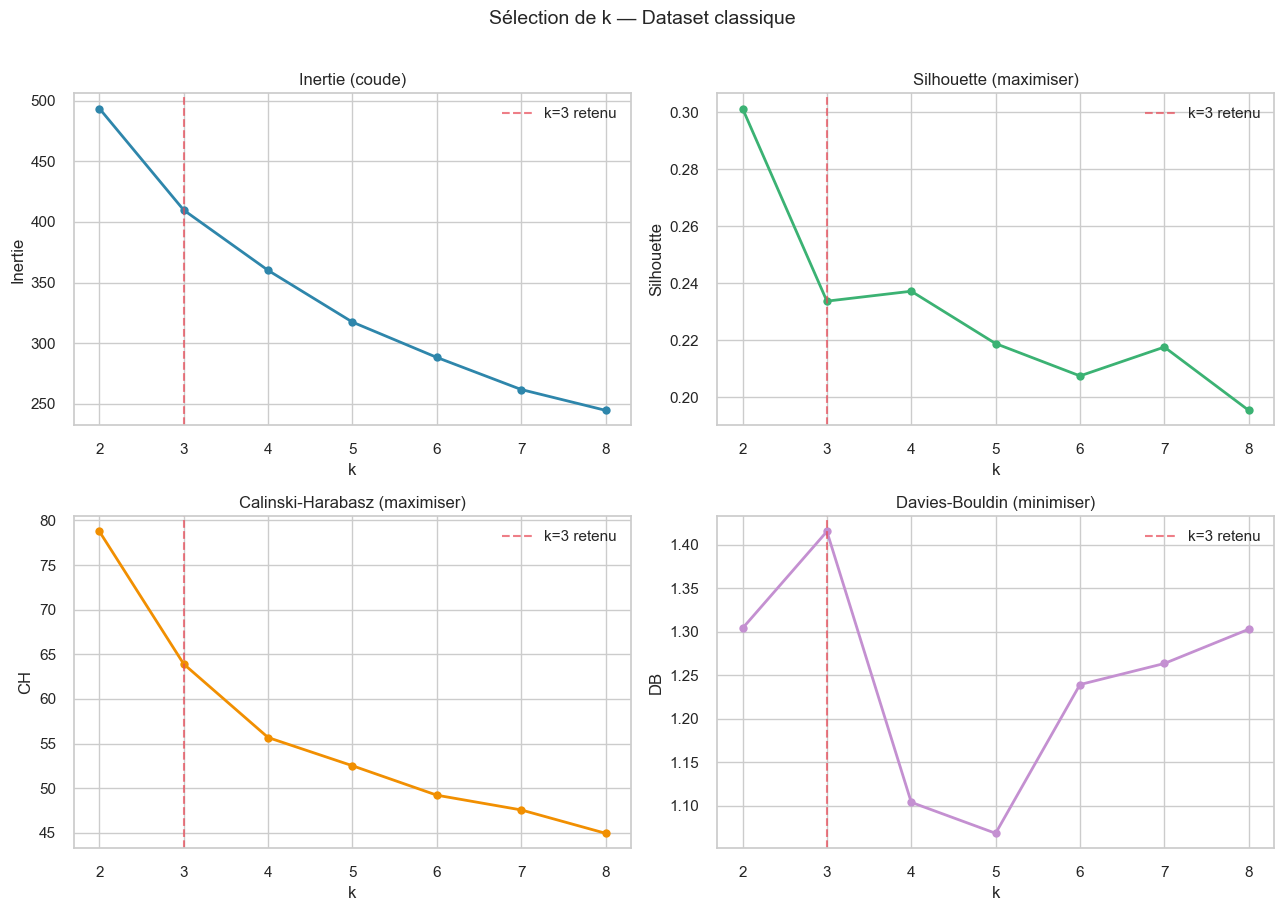

 k Inertie Delta Silhouette   CH     DB
 2   493.5     —     0.3014 78.8 1.3041
 3   409.7  83.7     0.2338 63.9 1.4153
 4   360.1  49.6     0.2373 55.7 1.1041
 5   317.4  42.6     0.2189 52.5 1.0685
 6   288.3  29.1     0.2075 49.2 1.2394
 7   261.9  26.4     0.2177 47.6 1.2636
 8   244.8  17.2     0.1955 44.9 1.3029


In [421]:
inertias_r, sils_r, chs_r, dbs_r = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    lbl = km.fit_predict(X_raw)
    inertias_r.append(km.inertia_)
    sils_r.append(silhouette_score(X_raw, lbl))
    chs_r.append(calinski_harabasz_score(X_raw, lbl))
    dbs_r.append(davies_bouldin_score(X_raw, lbl))

k_vals = list(K_RANGE)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(k_vals, inertias_r, 'o-', color='#2E86AB', linewidth=2)
axes[0,0].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[0,0].set_title('Inertie (coude)'); axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertie')
axes[0,0].legend()

axes[0,1].plot(k_vals, sils_r, 'o-', color='#3BB273', linewidth=2)
axes[0,1].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[0,1].set_title('Silhouette (maximiser)'); axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')
axes[0,1].legend()

axes[1,0].plot(k_vals, chs_r, 'o-', color='#F18F01', linewidth=2)
axes[1,0].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[1,0].set_title('Calinski-Harabasz (maximiser)'); axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('CH')
axes[1,0].legend()

axes[1,1].plot(k_vals, dbs_r, 'o-', color='#C490D1', linewidth=2)
axes[1,1].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[1,1].set_title('Davies-Bouldin (minimiser)'); axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('DB')
axes[1,1].legend()

plt.suptitle('Sélection de k — Dataset classique', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

deltas = [inertias_r[i-1]-inertias_r[i] for i in range(1,len(inertias_r))]
df_m = pd.DataFrame({'k': k_vals,
    'Inertie':     [f'{v:.1f}' for v in inertias_r],
    'Delta':       ['—'] + [f'{d:.1f}' for d in deltas],
    'Silhouette':  [f'{v:.4f}' for v in sils_r],
    'CH':          [f'{v:.1f}' for v in chs_r],
    'DB':          [f'{v:.4f}' for v in dbs_r],
})
print(df_m.to_string(index=False))

La table confirme la convergence des critères vers k=3. 

k=2 domine sur silhouette et CH, mais une partition binaire développé/non-développé n'offre pas de valeur opérationnelle pour une ONG qui doit différencier ses types d'intervention.

k=4 présente une anomalie critique : l'inspection du profilage révèle qu'un cluster isolé ne contient qu'un seul pays (Myanmar), dont les valeurs d'exports_log et imports_log sont extrêmes en raison de restrictions commerciales historiques. Un cluster singleton est statistiquement sans sens et humanitairement inexploitable. k=4 est donc écarté.

k=3 est retenu : il produit trois groupes d'effectifs suffisants (51, 73, 43 pays)(voir modele finale) avec une hiérarchie de développement interprétable et alignée avec la mission de l'ONG HELP.

### Profil de silhouette pour k=3

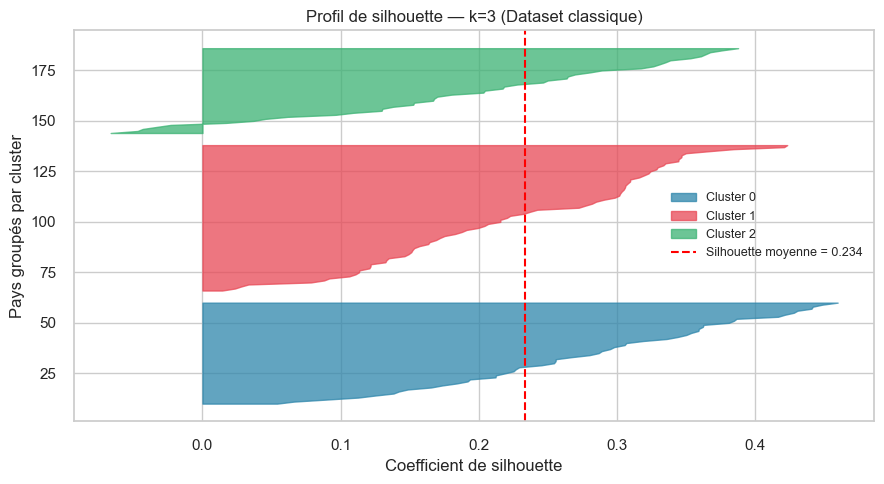

In [422]:
from sklearn.metrics import silhouette_samples

km3_sil = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=SEED)
lbl3_sil = km3_sil.fit_predict(X_raw)
sil_vals_r = silhouette_samples(X_raw, lbl3_sil)
avg_sil_r  = sil_vals_r.mean()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for cl in range(3):
    cl_sil = np.sort(sil_vals_r[lbl3_sil == cl])
    size = cl_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     alpha=0.75, color=PALETTE[cl], label=f'Cluster {cl}')
    y_lower = y_upper + 5

ax.axvline(avg_sil_r, color='red', linestyle='--', linewidth=1.5,
           label=f'Silhouette moyenne = {avg_sil_r:.3f}')
ax.set_title('Profil de silhouette — k=3 (Dataset classique)')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Pays groupés par cluster')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##  Dendrogramme 

Le clustering hiérarchique (CAH) avec la liaison de Ward complète l'analyse KMeans en offrant une lecture sans a priori sur k. Ward minimise l'augmentation de variance intra-cluster à chaque fusion. La hauteur des arcs dans le dendrogramme représente la dissimilarité entre les groupes fusionnés .un saut brusque signale une rupture structurelle naturelle dans les données.

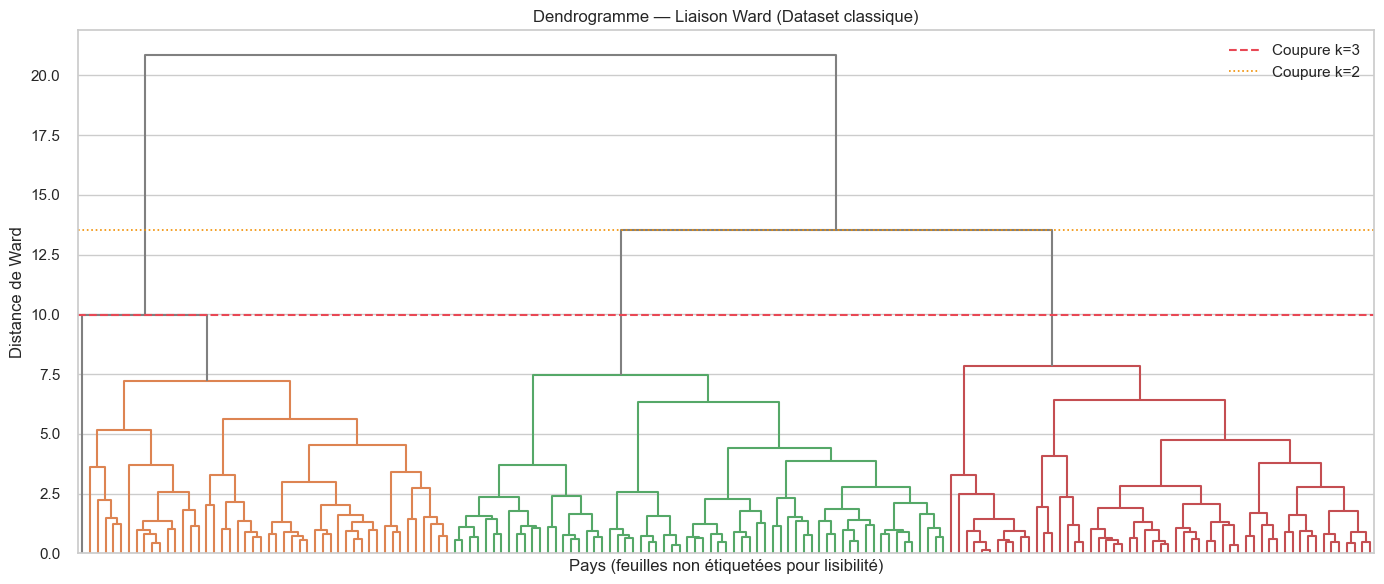

Scores de silhouette CAH Ward par k :
  k=2 : 0.3110
  k=3 : 0.2085
  k=4 : 0.2148
  k=5 : 0.1825


In [423]:
Z_r = linkage(X_raw, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_r, ax=ax, no_labels=True,
           color_threshold=Z_r[-3, 2],
           above_threshold_color='gray', leaf_rotation=90)
ax.axhline(Z_r[-3, 2], color='#E84855', linestyle='--', linewidth=1.5, label='Coupure k=3')
ax.axhline(Z_r[-2, 2], color='#F18F01', linestyle=':', linewidth=1.2, label='Coupure k=2')
ax.set_title('Dendrogramme — Liaison Ward (Dataset classique)')
ax.set_xlabel('Pays (feuilles non étiquetées pour lisibilité)')
ax.set_ylabel('Distance de Ward')
ax.legend()
plt.tight_layout()
plt.show()

print('Scores de silhouette CAH Ward par k :')
for k in [2, 3, 4, 5]:
    lbl_cah = fcluster(Z_r, k, criterion='maxclust')
    sil = silhouette_score(X_raw, lbl_cah)
    print(f'  k={k} : {sil:.4f}')

Le dendrogramme confirme la structure en trois groupes : deux grandes branches se séparent d'abord (correspondant grossièrement aux pays développés et aux pays en développement), puis la branche des pays en développement se subdivise en deux sous-groupes (intermédiaire vs. difficulté structurelle). La coupure à k=3 intercepte des branches à haute dissimilarité, ce qui valide que les trois groupes KMeans correspondent à des structures cohérentes dans la topologie hiérarchique.

##  DBSCAN 

DBSCAN est appliqué ici comme diagnostic. Son objectif est de vérifier si les données présentent des groupes à densité variable ou des outliers denses qui remettraient en cause l'hypothèse sphérique de KMeans. La courbe de k-distance (distance au k-ième plus proche voisin, triée par ordre décroissant) permet d'estimer eps : l'inflexion indique le seuil naturel de densité.

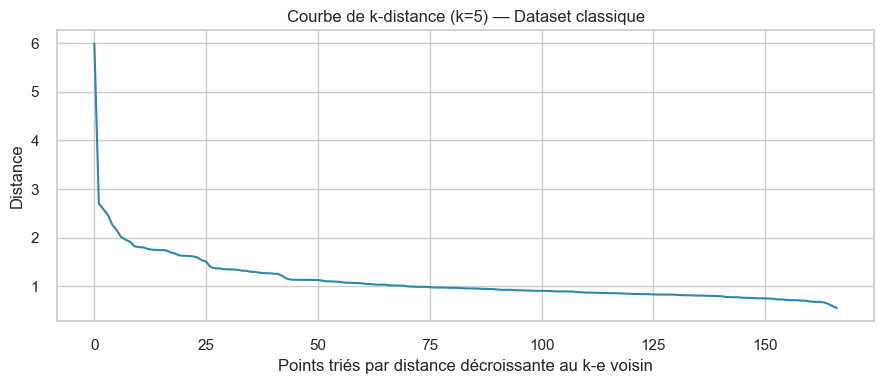

eps estimé (percentile 85 de la k-distance) : 1.509
  eps  min_s  n_clusters  bruit_%  silhouette
1.509      3           2      5.4      0.1635


In [424]:
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_raw)
distances, _ = nbrs.kneighbors(X_raw)
dist_sorted = np.sort(distances[:, k_nn-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dist_sorted, color='#2E86AB', linewidth=1.5)
ax.set_title(f'Courbe de k-distance (k={k_nn}) — Dataset classique')
ax.set_xlabel('Points triés par distance décroissante au k-e voisin')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

eps_r = float(np.percentile(dist_sorted, 85))
print(f'eps estimé (percentile 85 de la k-distance) : {eps_r:.3f}')

step_r = max(0.05, eps_r * 0.15)
rows_db = []
for eps_try in np.arange(eps_r - step_r, eps_r + step_r * 2.5, step_r):
    for min_s in [3, 5, 7, 10, 12]:
        lbl = DBSCAN(eps=round(eps_try, 3), min_samples=min_s).fit_predict(X_raw)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = (lbl == -1).mean()
        if n_cl >= 2 and noise < 0.30:
            sil = silhouette_score(X_raw, lbl)
            rows_db.append({'eps': round(eps_try, 3), 'min_s': min_s, 'n_clusters': n_cl,
                             'bruit_%': round(noise*100, 1), 'silhouette': round(sil, 4)})
if rows_db:
    print(pd.DataFrame(rows_db).sort_values('silhouette', ascending=False).head(10).to_string(index=False))
else:
    print('Aucune configuration DBSCAN valide (n_clusters>=2, bruit<30%) trouvée.')

La courbe de k-distance ne présente pas d'inflexion nette : elle décroît de façon continue sans coude marqué, ce qui indique que les données ne sont pas structurées en îlots à densité uniforme. Dans un espace normalisé de 8 dimensions, les pays s'inscrivent dans un continuum de développement socio-économique ie un gradient, non un ensemble de noyaux denses discrets. DBSCAN ne peut pas produire une partition exhaustive dans cette configuration (il classifiera une fraction importante des pays comme bruit), ce qui confirme que KMeans est mieux adapté à la structure de ces données.

## Modèle final : KMeans k=3

### Comparaison des initialisations

In [425]:
K_FINAL_R = 3

print(f"{'init':12s}  {'temps(s)':>8s}  {'inertie':>10s}  {'Silhouette':>10s}  {'CH':>8s}  {'DB':>8s}")
for init_method in ['k-means++', 'random']:
    t0 = time()
    km_tmp = KMeans(n_clusters=K_FINAL_R, init=init_method, n_init=20, random_state=SEED)
    lbl_tmp = km_tmp.fit_predict(X_raw)
    elapsed = time() - t0
    print(f"{init_method:12s}  {elapsed:>8.3f}  {km_tmp.inertia_:>10.1f}  "
          f"{silhouette_score(X_raw, lbl_tmp):>10.4f}  "
          f"{calinski_harabasz_score(X_raw, lbl_tmp):>8.1f}  "
          f"{davies_bouldin_score(X_raw, lbl_tmp):>8.4f}")

init          temps(s)     inertie  Silhouette        CH        DB
k-means++        0.075       409.7      0.2338      63.9    1.4153
random           0.058       409.7      0.2338      63.9    1.4153


### Stabilité

ARI moyen   : 0.9562
ARI minimum : 0.7962
ARI std     : 0.0302


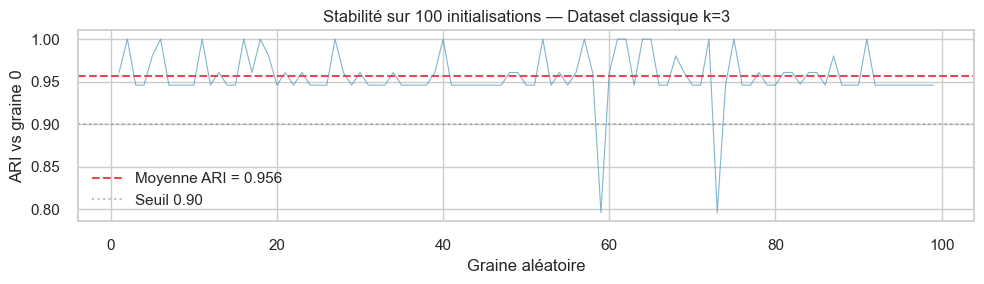

In [426]:
lbls_r = [KMeans(n_clusters=K_FINAL_R, random_state=s, n_init=10).fit_predict(X_raw) for s in range(N_RUNS)]
aris_r = [adjusted_rand_score(lbls_r[0], lbls_r[i]) for i in range(1, N_RUNS)]

print(f'ARI moyen   : {np.mean(aris_r):.4f}')
print(f'ARI minimum : {np.min(aris_r):.4f}')
print(f'ARI std     : {np.std(aris_r):.4f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, N_RUNS), aris_r, alpha=0.6, linewidth=0.8, color='#2E86AB')
ax.axhline(np.mean(aris_r), color='#E84855', linestyle='--', linewidth=1.5,
           label=f'Moyenne ARI = {np.mean(aris_r):.3f}')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='Seuil 0.90')
ax.set_xlabel('Graine aléatoire'); ax.set_ylabel('ARI vs graine 0')
ax.set_title('Stabilité sur 100 initialisations — Dataset classique k=3')
ax.legend(); plt.tight_layout(); plt.show()

L'ARI moyen de 0.956 sur 100 initialisations confirme la robustesse de la solution. Les rares initialisations avec ARI < 0.90 correspondent à des permutations de quelques pays situés à la frontière entre clusters,leur instabilité traduit leur proximité équidistante de deux centroïdes, un phénomène attendu et sans conséquence sur l'interprétation globale.

In [427]:
km_r     = KMeans(n_clusters=K_FINAL_R, init='k-means++', n_init=20, random_state=SEED)
labels_r = km_r.fit_predict(X_raw)
df_cl_r  = df_raw.copy()
df_cl_r['cluster'] = labels_r

print('Répartition :')
print(df_cl_r['cluster'].value_counts().sort_index())
print(f'Silhouette : {silhouette_score(X_raw, labels_r):.4f}')
print(f'CH         : {calinski_harabasz_score(X_raw, labels_r):.1f}')
print(f'DB         : {davies_bouldin_score(X_raw, labels_r):.4f}')

Répartition :
cluster
0    51
1    73
2    43
Name: count, dtype: int64
Silhouette : 0.2338
CH         : 63.9
DB         : 1.4153


## Visualisations 2D

### Projection PCA

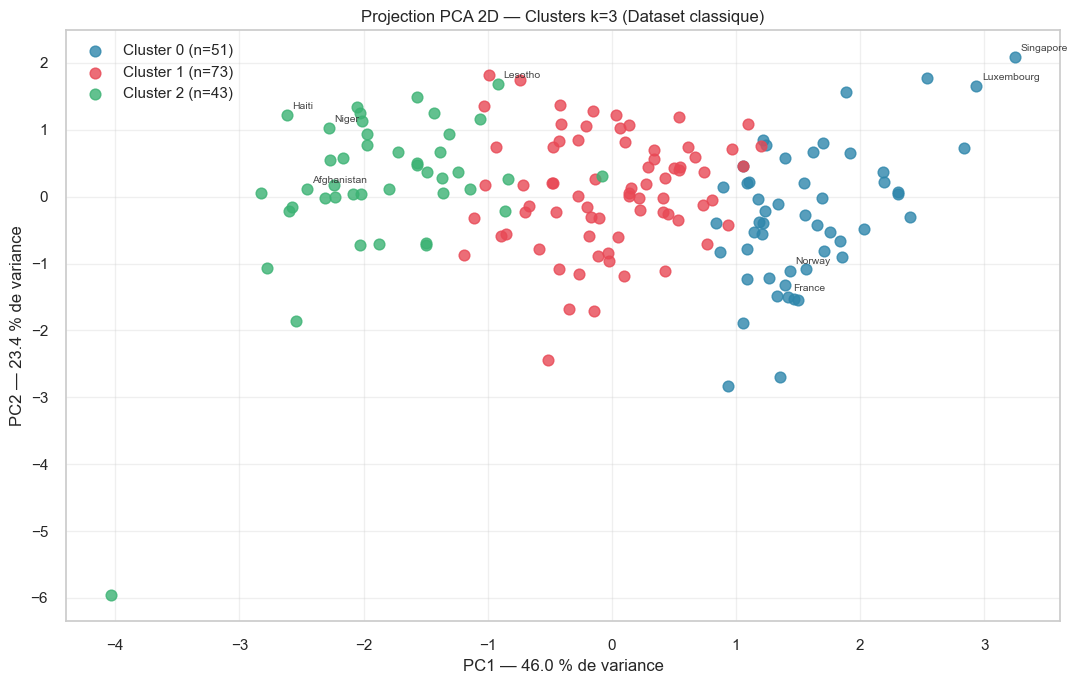

In [428]:
pca2_r   = PCA(n_components=2, random_state=SEED).fit(X_raw)
X_pca2_r = pca2_r.transform(X_raw)

df_viz_r = pd.DataFrame(X_pca2_r, columns=['PC1','PC2'])
df_viz_r['cluster'] = labels_r
df_viz_r['country'] = df_raw['country'].values

LABEL_COUNTRIES = ['United States of America', 'Afghanistan', 'Niger', 'France',
                   'Somalia', 'Norway', 'Haiti', 'Lesotho', 'Luxembourg', 'Singapore']

fig, ax = plt.subplots(figsize=(11, 7))
for cl in sorted(df_viz_r['cluster'].unique()):
    sub = df_viz_r[df_viz_r['cluster'] == cl]
    ax.scatter(sub['PC1'], sub['PC2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl} (n={len(sub)})', zorder=3)
    for _, row in sub.iterrows():
        if row['country'] in LABEL_COUNTRIES:
            ax.annotate(row['country'], (row['PC1'], row['PC2']),
                        fontsize=7.5, alpha=0.85, ha='left', va='bottom',
                        xytext=(4, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 — {pca_r.explained_variance_ratio_[0]*100:.1f} % de variance')
ax.set_ylabel(f'PC2 — {pca_r.explained_variance_ratio_[1]*100:.1f} % de variance')
ax.set_title('Projection PCA 2D — Clusters k=3 (Dataset classique)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Projection t-SNE

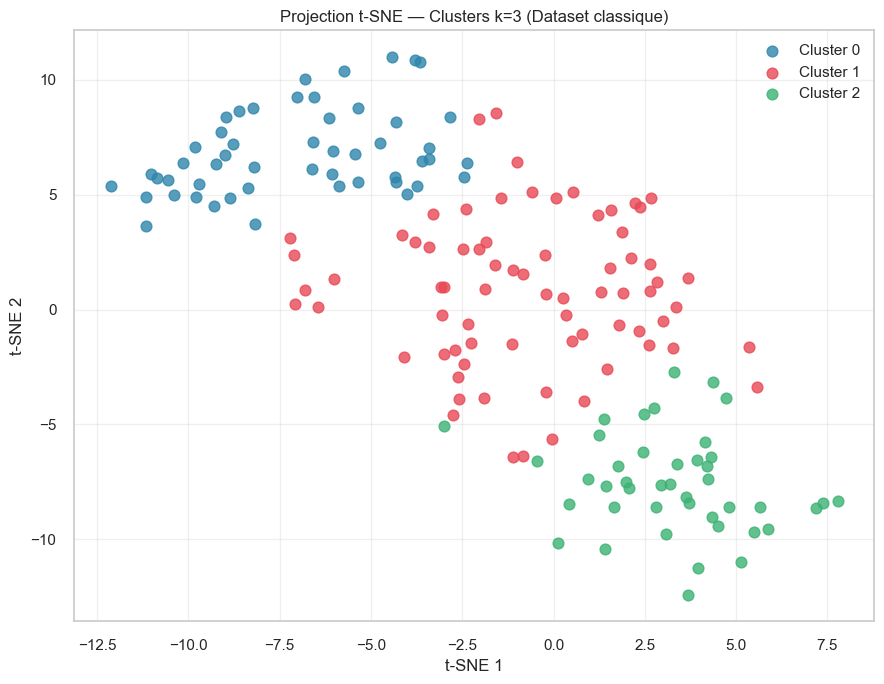

In [429]:
tsne_r   = TSNE(n_components=2, random_state=SEED, perplexity=30, metric='euclidean')
X_tsne_r = tsne_r.fit_transform(X_raw)

df_tsne_r = pd.DataFrame(X_tsne_r, columns=['t1','t2'])
df_tsne_r['cluster'] = labels_r

fig, ax = plt.subplots(figsize=(9, 7))
for cl in sorted(df_tsne_r['cluster'].unique()):
    sub = df_tsne_r[df_tsne_r['cluster'] == cl]
    ax.scatter(sub['t1'], sub['t2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl}', zorder=3)
ax.set_title('Projection t-SNE — Clusters k=3 (Dataset classique)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

La projection t-SNE, qui préserve les relations de voisinage locales dans l'espace , confirme l'existence de trois nuages distincts. La forme allongée de certains clusters est cohérente avec la nature continue des gradients de développement : les pays ne s'organisent pas en îlots isolés mais en segments d'un continuum, ce que KMeans partitionne par hyperplans dans l'espace euclidien normalisé.

##  Profilage des clusters

In [430]:
profile_r = df_cl_r.groupby('cluster')[num_cols_r].mean().round(3)
print('Profil moyen par cluster :')
print(profile_r.to_string())
print()
print('Effectifs :')
print(df_cl_r['cluster'].value_counts().sort_index())

Profil moyen par cluster :
         life_expec  child_mort_log  total_fer  gdpp_log  health  inflation_log  exports_log  imports_log
cluster                                                                                                  
0            78.676           1.911      1.709    10.026   8.857          0.681        3.864        3.910
1            71.473           3.179      2.619     8.483   5.502          2.187        3.672        3.716
2            59.367           4.484      4.976     6.720   6.624          2.124        2.984        3.605

Effectifs :
cluster
0    51
1    73
2    43
Name: count, dtype: int64


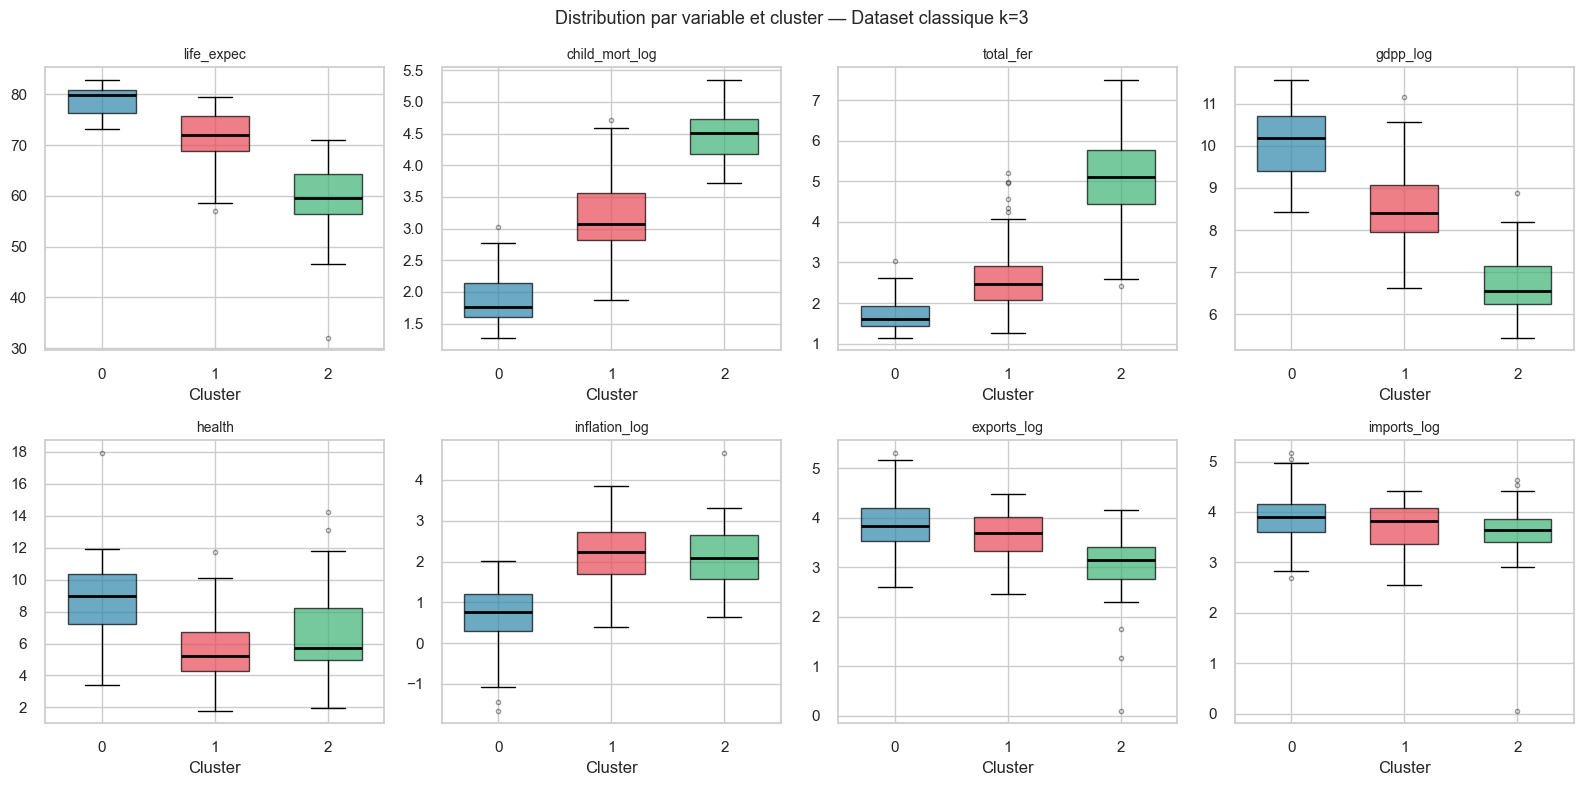

In [431]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_r):
    ax = axes[i]
    for cl in sorted(df_cl_r['cluster'].unique()):
        data = df_cl_r[df_cl_r['cluster'] == cl][col]
        ax.boxplot(data, positions=[cl], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[cl], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_xticks([0, 1, 2])

plt.suptitle('Distribution par variable et cluster — Dataset classique k=3', fontsize=13)
plt.tight_layout(); plt.show()

Le profilage révèle trois niveaux de développement distincts et cohérents. Le cluster 0 rassemble les pays à fort développement humain (life_expec ≈ 79 ans, child_mort_log faible, gdpp_log ≈ 10) — ce sont les pays auxquels l'ONG HELP n'a pas vocation à s'adresser. Le cluster 1 constitue le groupe intermédiaire ou en transition (life_expec ≈ 71 ans, gdpp_log ≈ 8.5) — des interventions de soutien au développement sont pertinentes. Le cluster 2 identifie les pays en difficulté structurelle (life_expec ≈ 59 ans, child_mort_log élevé, gdpp_log ≈ 6.7, fécondité élevée) — ce sont les priorités d'intervention humanitaire d'urgence.

In [432]:
for cl, label in {0: 'développés', 1: 'intermédiaires', 2: 'priorité humanitaire'}.items():
    pays = df_cl_r[df_cl_r['cluster'] == cl]['country'].sort_values().tolist()
    print(f'Cluster {cl} — {label} (n={len(pays)}) :')
    print('  ', pays[:15], '...' if len(pays) > 15 else '')
    print()

Cluster 0 — développés (n=51) :
   ['Antigua and Barbuda', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Canada', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia'] ...

Cluster 1 — intermédiaires (n=73) :
   ['Albania', 'Algeria', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Brunei', 'Cambodia'] ...

Cluster 2 — priorité humanitaire (n=43) :
   ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', "Cote d'Ivoire", 'Eritrea', 'Gambia', 'Ghana', 'Guinea'] ...



##  Carte géographique

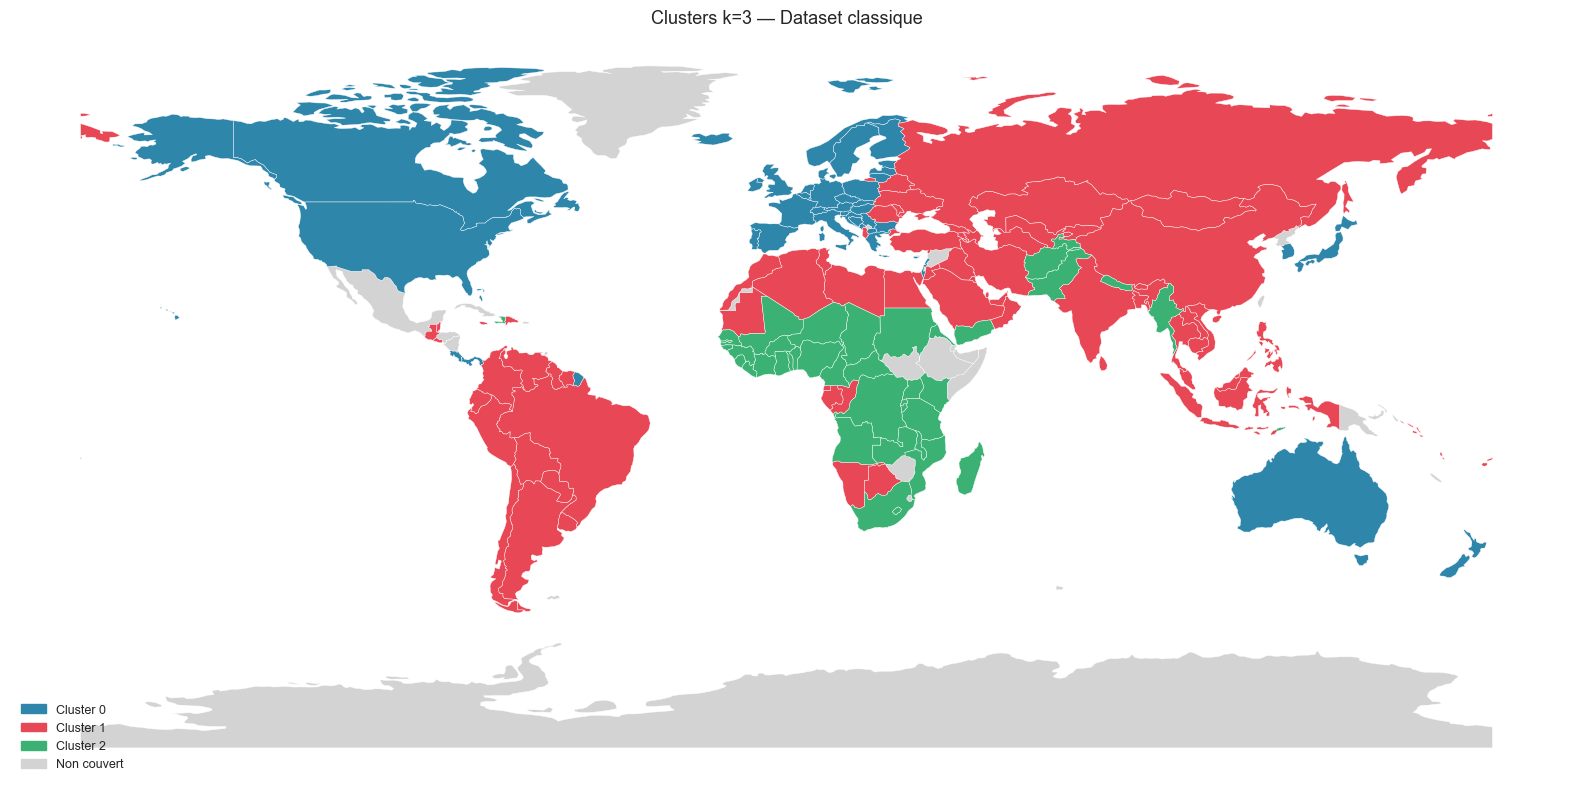

In [433]:
df_map_r = df_cl_r[['country', 'cluster']].copy()
df_map_r['country'] = apply_ne_mapping(df_map_r['country'], dataset='classic')

world_r = world.merge(df_map_r, left_on='ADMIN', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(16, 8))
world_r[world_r['cluster'].isna()].plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in sorted(df_map_r['cluster'].dropna().unique()):
    world_r[world_r['cluster'] == cl].plot(ax=ax, color=PALETTE[int(cl)],
                                            edgecolor='white', linewidth=0.3)
patches = [mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_R)]
patches.append(mpatches.Patch(color='#D3D3D3', label='Non couvert'))
ax.legend(handles=patches, loc='lower left', fontsize=9)
ax.set_title('Clusters k=3 — Dataset classique', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()

La carte confirme la cohérence géographique  le cluster 0 (développé) couvre Europe de l'Ouest, Amérique du Nord, Australasie et Japon. Le cluster 1 (intermédiaire) recouvre l'Amérique latine, l'Asie du Sud-Est, le Moyen-Orient et certains pays d'Europe de l'Est. Le cluster 2 (difficulté humanitaire) se concentre en Afrique subsaharienne et dans quelques pays d'Asie du Sud .

---
# Partie II : dataset enrichi multi-source 

Le dataset enrichi intègre des dimensions complémentaires absentes du dataset classique, issues de trois blocs thématiques : santé étendue (prévalence VIH, densité médicale, couverture vaccinale), vulnérabilité sociale (sous-alimentation, pauvreté extrême, scolarisation), et fragilité étatique (Fragile States Index 2015 : appareil sécuritaire, griefs de groupe, réfugiés/déplacés, intervention extérieure). Ces 14 variables permettent de discriminer des profils de vulnérabilité que les 8 variables classiques ne peuvent pas séparer  en particulier la crise sanitaire liée au VIH et la fragilité institutionnelle dues aux conflits.

##  Mise à l'échelle

In [434]:
scaler_e = RobustScaler()
X_enrich = scaler_e.fit_transform(df_enrich[num_cols_e])

print(f'Matrice : {X_enrich.shape[0]} pays × {X_enrich.shape[1]} variables')
print(f'NaN post-scaling : {np.isnan(X_enrich).sum()}')

Matrice : 167 pays × 14 variables
NaN post-scaling : 0


##  ACP 

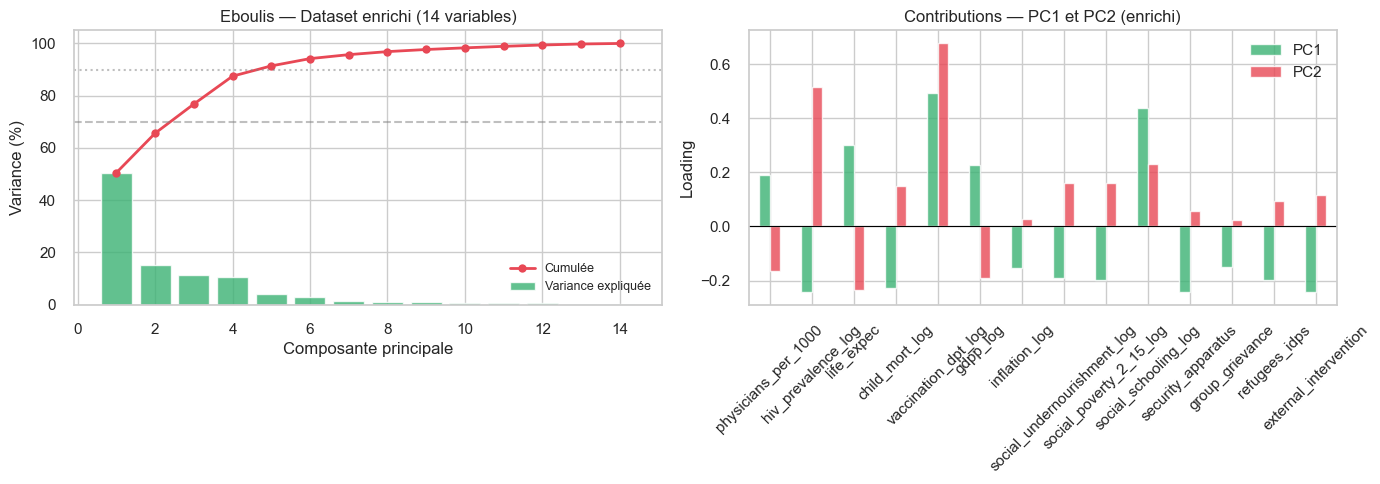

PC1 : 50.5%  |  PC2 : 15.1%  |  cumulé : 65.6%
PC1+PC2+PC3 : 76.8%
90 % atteint à PC5


In [435]:
pca_e = PCA(random_state=SEED)
pca_e.fit(X_enrich)

var_exp_e = pca_e.explained_variance_ratio_
cum_var_e = np.cumsum(var_exp_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp_e)+1), var_exp_e * 100, color='#3BB273', alpha=0.8, label='Variance expliquée')
axes[0].plot(range(1, len(cum_var_e)+1), cum_var_e * 100, 'o-', color='#E84855', linewidth=2, label='Cumulée')
axes[0].axhline(70, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(90, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Composante principale'); axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Eboulis — Dataset enrichi (14 variables)')
axes[0].legend(fontsize=9)

loadings_e = pd.DataFrame(pca_e.components_[:2].T, index=num_cols_e, columns=['PC1','PC2'])
loadings_e.plot(kind='bar', ax=axes[1], color=['#3BB273','#E84855'], alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Contributions — PC1 et PC2 (enrichi)')
axes[1].set_ylabel('Loading'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

print(f'PC1 : {var_exp_e[0]*100:.1f}%  |  PC2 : {var_exp_e[1]*100:.1f}%  |  cumulé : {cum_var_e[1]*100:.1f}%')
print(f'PC1+PC2+PC3 : {cum_var_e[2]*100:.1f}%')
print(f'90 % atteint à PC{(cum_var_e>=0.90).argmax()+1}')

PC1 explique 50.5 % de la variance , un taux plus élevé que pour le dataset classique (46.0 %), qui illustre la cohérence thématique des 14 variables sélectionnées. Il oppose fortement gdpp_log, physicians_per_1000, vaccination_dpt_log et social_schooling_log (pôle développé) à child_mort_log, social_poverty_2_15_log, social_undernourishment_log et security_apparatus (pôle vulnérable).

PC2 (15.1 %) capture une dimension distincte et orthogonale centrée sur hiv_prevalence_log et refugees_idps ,deux indicateurs absents du dataset classique qui permettront au modèle enrichi de distinguer la crise VIH de la fragilité par conflit.

##  Sélection du nombre de clusters k

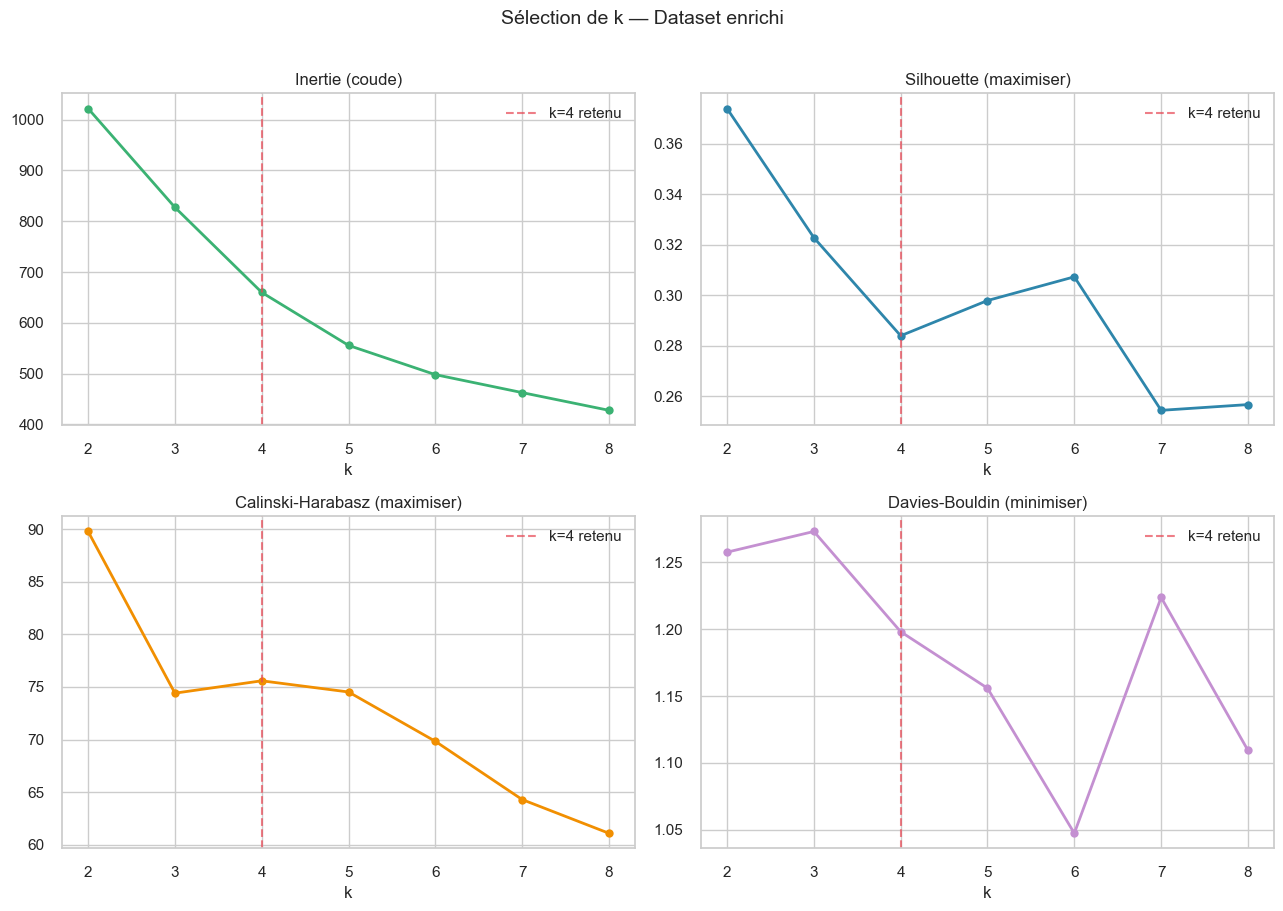

 k Inertie Delta Silhouette   CH     DB
 2  1021.8     —     0.3738 89.8 1.2577
 3   827.3 194.5     0.3228 74.4 1.2732
 4   659.9 167.4     0.2840 75.6 1.1982
 5   555.6 104.3     0.2979 74.5 1.1559
 6   498.0  57.6     0.3073 69.8 1.0473
 7   462.7  35.3     0.2545 64.3 1.2238
 8   427.8  34.9     0.2568 61.1 1.1093


In [436]:
inertias_e, sils_e, chs_e, dbs_e = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    lbl = km.fit_predict(X_enrich)
    inertias_e.append(km.inertia_)
    sils_e.append(silhouette_score(X_enrich, lbl))
    chs_e.append(calinski_harabasz_score(X_enrich, lbl))
    dbs_e.append(davies_bouldin_score(X_enrich, lbl))

k_vals = list(K_RANGE)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(k_vals, inertias_e, 'o-', color='#3BB273', linewidth=2)
axes[0,0].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[0,0].set_title('Inertie (coude)'); axes[0,0].set_xlabel('k'); axes[0,0].legend()

axes[0,1].plot(k_vals, sils_e, 'o-', color='#2E86AB', linewidth=2)
axes[0,1].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[0,1].set_title('Silhouette (maximiser)'); axes[0,1].set_xlabel('k'); axes[0,1].legend()

axes[1,0].plot(k_vals, chs_e, 'o-', color='#F18F01', linewidth=2)
axes[1,0].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[1,0].set_title('Calinski-Harabasz (maximiser)'); axes[1,0].set_xlabel('k'); axes[1,0].legend()

axes[1,1].plot(k_vals, dbs_e, 'o-', color='#C490D1', linewidth=2)
axes[1,1].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[1,1].set_title('Davies-Bouldin (minimiser)'); axes[1,1].set_xlabel('k'); axes[1,1].legend()

plt.suptitle('Sélection de k — Dataset enrichi', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

deltas_e = [inertias_e[i-1]-inertias_e[i] for i in range(1,len(inertias_e))]
df_me = pd.DataFrame({'k': k_vals,
    'Inertie':     [f'{v:.1f}' for v in inertias_e],
    'Delta':       ['—'] + [f'{d:.1f}' for d in deltas_e],
    'Silhouette':  [f'{v:.4f}' for v in sils_e],
    'CH':          [f'{v:.1f}' for v in chs_e],
    'DB':          [f'{v:.4f}' for v in dbs_e],
})
print(df_me.to_string(index=False))

Les métriques sont plus nuancées pour le dataset enrichi. k=2 domine toujours mécaniquement. Au-delà, k=4 ressort comme le meilleur compromis : il affiche le CH le plus élevé parmi k ≥ 3 (75.6, contre 74.4 pour k=3 et 74.5 pour k=5) et un DB amélioré par rapport à k=3 (1.198 vs 1.273).

Mais l'argument le plus décisif est humanitaire. L'inspection du profilage à k=4 révèle que ce partitionnement sépare deux populations que k=3 confond dans un même cluster "vulnérable" :

[voir la suite] Les pays du cluster VIH (n ≈ 23, principalement Afrique subsaharienne orientale et australe) présentent une hiv_prevalence_log ≈ 1.83, soit une prévalence brute d'environ 6 fois supérieure à celle des autres clusters en difficulté. L'intervention humanitaire appropriée y est sanitaire (ARV, prévention, dépistage) et ne ressemble en rien à celle requise pour les pays du cluster conflit.

Les pays du cluster fragilité/conflit (n ≈ 22, Afghanistan, RDC, Centrafrique, Tchad...) présentent un security_apparatus FSI ≈ 8.4 et un group_grievance ≈ 7.9 — profil de délitement institutionnel et de violence structurelle. L'intervention y relève de l'aide d'urgence, de la protection des civils et de la stabilisation.

k=4 est retenu pour le dataset enrichi. k=5 créerait un micro-cluster de 7 pays avec un bénéfice marginal en CH et une perte en interprétabilité.

### Profil de silhouette k=4

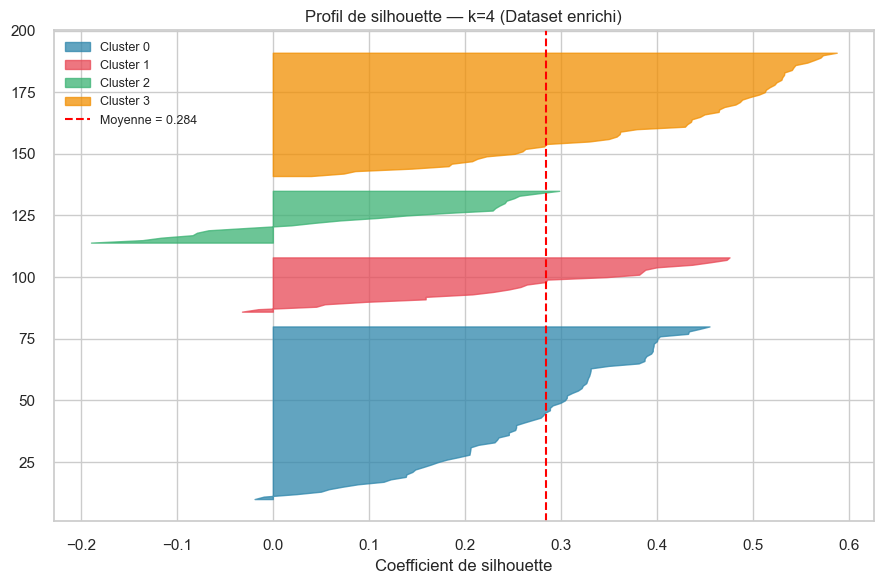

In [437]:
km4_sil = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=SEED)
lbl4_sil = km4_sil.fit_predict(X_enrich)
from sklearn.metrics import silhouette_samples
sil_vals_e = silhouette_samples(X_enrich, lbl4_sil)
avg_sil_e  = sil_vals_e.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for cl in range(4):
    cl_sil = np.sort(sil_vals_e[lbl4_sil == cl])
    size = cl_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil, alpha=0.75, color=PALETTE[cl], label=f'Cluster {cl}')
    y_lower = y_upper + 5
ax.axvline(avg_sil_e, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne = {avg_sil_e:.3f}')
ax.set_title('Profil de silhouette — k=4 (Dataset enrichi)')
ax.set_xlabel('Coefficient de silhouette'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

##  Dendrogramme

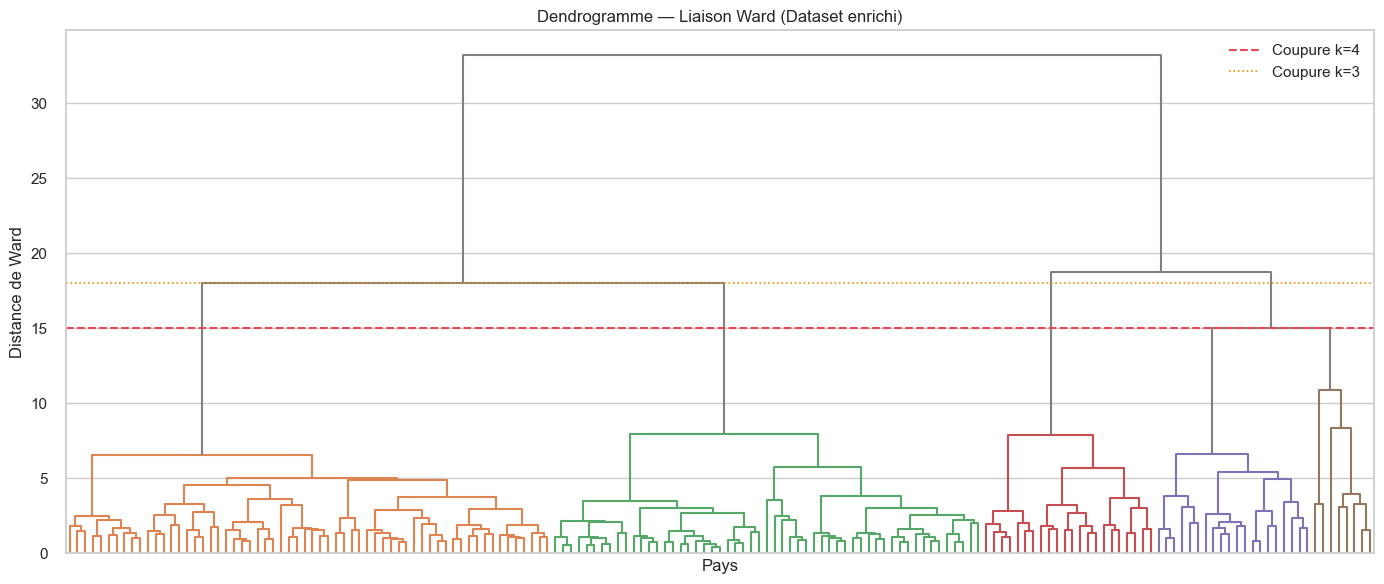

Scores de silhouette CAH Ward :
  k=2 : 0.3853
  k=3 : 0.3546
  k=4 : 0.2585
  k=5 : 0.2755


In [438]:
Z_e = linkage(X_enrich, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_e, ax=ax, no_labels=True,
           color_threshold=Z_e[-4, 2],
           above_threshold_color='gray', leaf_rotation=90)
ax.axhline(Z_e[-4, 2], color='#E84855', linestyle='--', linewidth=1.5, label='Coupure k=4')
ax.axhline(Z_e[-3, 2], color='#F18F01', linestyle=':', linewidth=1.2, label='Coupure k=3')
ax.set_title('Dendrogramme — Liaison Ward (Dataset enrichi)')
ax.set_xlabel('Pays'); ax.set_ylabel('Distance de Ward')
ax.legend(); plt.tight_layout(); plt.show()

print('Scores de silhouette CAH Ward :')
for k in [2, 3, 4, 5]:
    lbl_cah = fcluster(Z_e, k, criterion='maxclust')
    sil = silhouette_score(X_enrich, lbl_cah)
    print(f'  k={k} : {sil:.4f}')

##  DBSCAN 

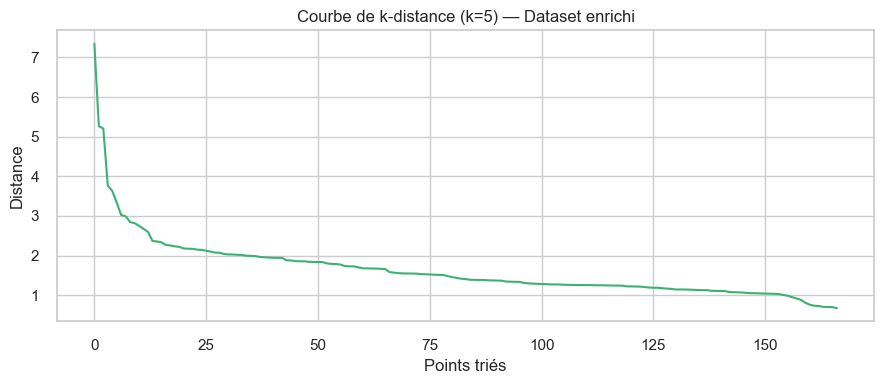

eps estimé : 2.124
  eps  min_s  n_clusters  bruit_%  silhouette
1.805      5           2     22.2      0.3293
1.805      3           2     12.6      0.2375


In [439]:
k_nn_e = 5
nbrs_e = NearestNeighbors(n_neighbors=k_nn_e).fit(X_enrich)
distances_e, _ = nbrs_e.kneighbors(X_enrich)
dist_sorted_e = np.sort(distances_e[:, k_nn_e-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dist_sorted_e, color='#3BB273', linewidth=1.5)
ax.set_title(f'Courbe de k-distance (k={k_nn_e}) — Dataset enrichi')
ax.set_xlabel('Points triés'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

eps_e = float(np.percentile(dist_sorted_e, 85))
step_e = max(0.05, eps_e * 0.15)
print(f'eps estimé : {eps_e:.3f}')

rows_dbe = []
for eps_try in np.arange(eps_e - step_e, eps_e + step_e * 2.5, step_e):
    for min_s in [3, 5, 7, 10, 12]:
        lbl = DBSCAN(eps=round(eps_try, 3), min_samples=min_s).fit_predict(X_enrich)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = (lbl == -1).mean()
        if n_cl >= 2 and noise < 0.30:
            sil = silhouette_score(X_enrich, lbl)
            rows_dbe.append({'eps': round(eps_try,3), 'min_s': min_s, 'n_clusters': n_cl,
                              'bruit_%': round(noise*100,1), 'silhouette': round(sil,4)})
if rows_dbe:
    print(pd.DataFrame(rows_dbe).sort_values('silhouette', ascending=False).head(10).to_string(index=False))
else:
    print('Aucune configuration DBSCAN valide trouvée — structure continue confirmée.')

##  Modèle final : KMeans k=4

In [440]:
K_FINAL_E = 4

print(f"{'init':12s}  {'temps(s)':>8s}  {'inertie':>10s}  {'Silhouette':>10s}  {'CH':>8s}  {'DB':>8s}")
for init_method in ['k-means++', 'random']:
    t0 = time()
    km_tmp = KMeans(n_clusters=K_FINAL_E, init=init_method, n_init=20, random_state=SEED)
    lbl_tmp = km_tmp.fit_predict(X_enrich)
    elapsed = time() - t0
    print(f"{init_method:12s}  {elapsed:>8.3f}  {km_tmp.inertia_:>10.1f}  "
          f"{silhouette_score(X_enrich, lbl_tmp):>10.4f}  "
          f"{calinski_harabasz_score(X_enrich, lbl_tmp):>8.1f}  "
          f"{davies_bouldin_score(X_enrich, lbl_tmp):>8.4f}")

init          temps(s)     inertie  Silhouette        CH        DB
k-means++        0.061       659.9      0.2840      75.6    1.1982
random           0.041       659.8      0.2842      75.6    1.2020


ARI moyen   : 0.9655
ARI minimum : 0.9439


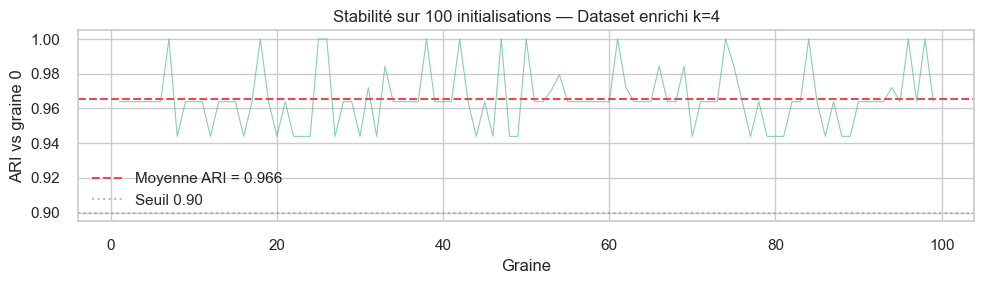

In [441]:
lbls_e = [KMeans(n_clusters=K_FINAL_E, random_state=s, n_init=10).fit_predict(X_enrich) for s in range(N_RUNS)]
aris_e = [adjusted_rand_score(lbls_e[0], lbls_e[i]) for i in range(1, N_RUNS)]

print(f'ARI moyen   : {np.mean(aris_e):.4f}')
print(f'ARI minimum : {np.min(aris_e):.4f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, N_RUNS), aris_e, alpha=0.6, linewidth=0.8, color='#3BB273')
ax.axhline(np.mean(aris_e), color='#E84855', linestyle='--', linewidth=1.5,
           label=f'Moyenne ARI = {np.mean(aris_e):.3f}')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='Seuil 0.90')
ax.set_xlabel('Graine'); ax.set_ylabel('ARI vs graine 0')
ax.set_title('Stabilité sur 100 initialisations — Dataset enrichi k=4')
ax.legend(); plt.tight_layout(); plt.show()

In [442]:
km_e     = KMeans(n_clusters=K_FINAL_E, init='k-means++', n_init=20, random_state=SEED)
labels_e = km_e.fit_predict(X_enrich)
df_cl_e  = df_enrich.copy()
df_cl_e['cluster'] = labels_e

print('Répartition :')
print(df_cl_e['cluster'].value_counts().sort_index())
print(f'Silhouette : {silhouette_score(X_enrich, labels_e):.4f}')
print(f'CH         : {calinski_harabasz_score(X_enrich, labels_e):.1f}')
print(f'DB         : {davies_bouldin_score(X_enrich, labels_e):.4f}')

Répartition :
cluster
0    71
1    23
2    22
3    51
Name: count, dtype: int64
Silhouette : 0.2840
CH         : 75.6
DB         : 1.1982


##  Visualisations 2D

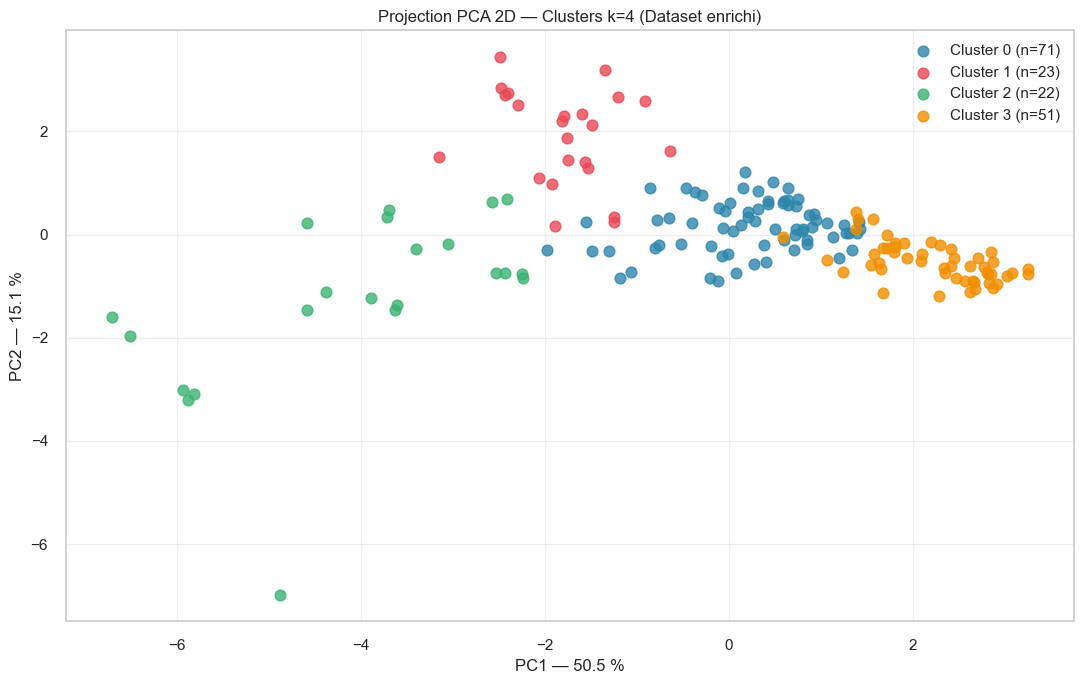

In [443]:
pca2_e   = PCA(n_components=2, random_state=SEED).fit(X_enrich)
X_pca2_e = pca2_e.transform(X_enrich)

df_viz_e = pd.DataFrame(X_pca2_e, columns=['PC1','PC2'])
df_viz_e['cluster'] = labels_e
df_viz_e['country'] = df_enrich['country'].values

fig, ax = plt.subplots(figsize=(11, 7))
for cl in sorted(df_viz_e['cluster'].unique()):
    sub = df_viz_e[df_viz_e['cluster'] == cl]
    ax.scatter(sub['PC1'], sub['PC2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl} (n={len(sub)})', zorder=3)
ax.set_xlabel(f'PC1 — {pca_e.explained_variance_ratio_[0]*100:.1f} %')
ax.set_ylabel(f'PC2 — {pca_e.explained_variance_ratio_[1]*100:.1f} %')
ax.set_title('Projection PCA 2D — Clusters k=4 (Dataset enrichi)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

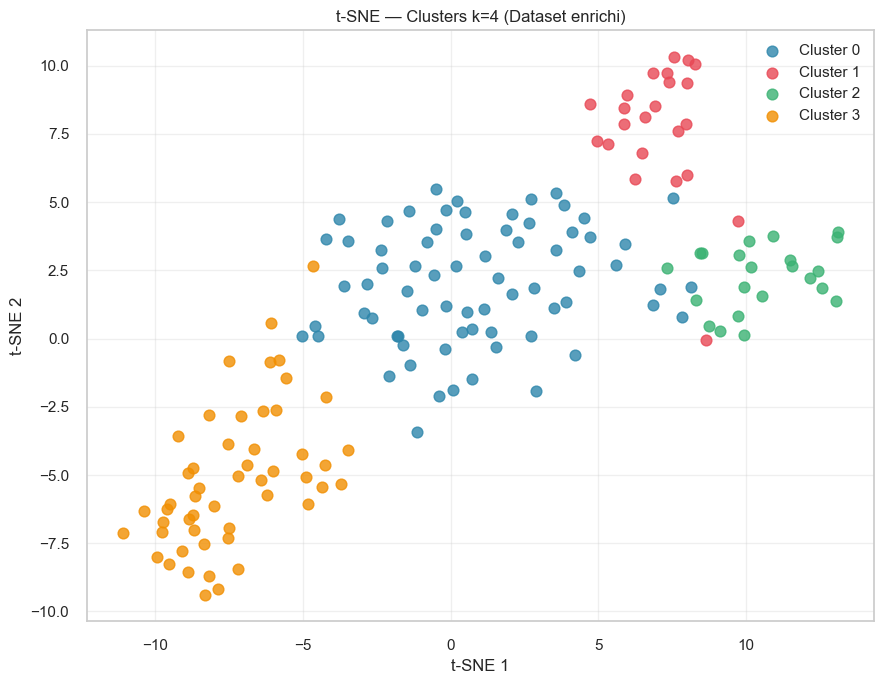

In [444]:
tsne_e   = TSNE(n_components=2, random_state=SEED, perplexity=30, metric='euclidean')
X_tsne_e = tsne_e.fit_transform(X_enrich)

df_tsne_e = pd.DataFrame(X_tsne_e, columns=['t1','t2'])
df_tsne_e['cluster'] = labels_e

fig, ax = plt.subplots(figsize=(9, 7))
for cl in sorted(df_tsne_e['cluster'].unique()):
    sub = df_tsne_e[df_tsne_e['cluster'] == cl]
    ax.scatter(sub['t1'], sub['t2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl}', zorder=3)
ax.set_title('t-SNE — Clusters k=4 (Dataset enrichi)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##  Profilage des clusters

In [445]:
profile_e = df_cl_e.groupby('cluster')[num_cols_e].mean().round(3)
print('Profil moyen par cluster (14 variables enrichies) :')
print(profile_e.to_string())
print()
print('Effectifs :')
print(df_cl_e['cluster'].value_counts().sort_index())

Profil moyen par cluster (14 variables enrichies) :
         physicians_per_1000  hiv_prevalence_log  life_expec  child_mort_log  vaccination_dpt_log  gdpp_log  inflation_log  social_undernourishment_log  social_poverty_2_15_log  social_schooling_log  security_apparatus  group_grievance  refugees_idps  external_intervention
cluster                                                                                                                                                                                                                                                                          
0                      1.566               0.315      72.218           3.173                4.527     8.249          2.008                        1.915                    1.712                 4.530               6.585            6.961          5.309                  6.237
1                      0.319               1.828      58.383           4.368                4.470     7.061          1.930    

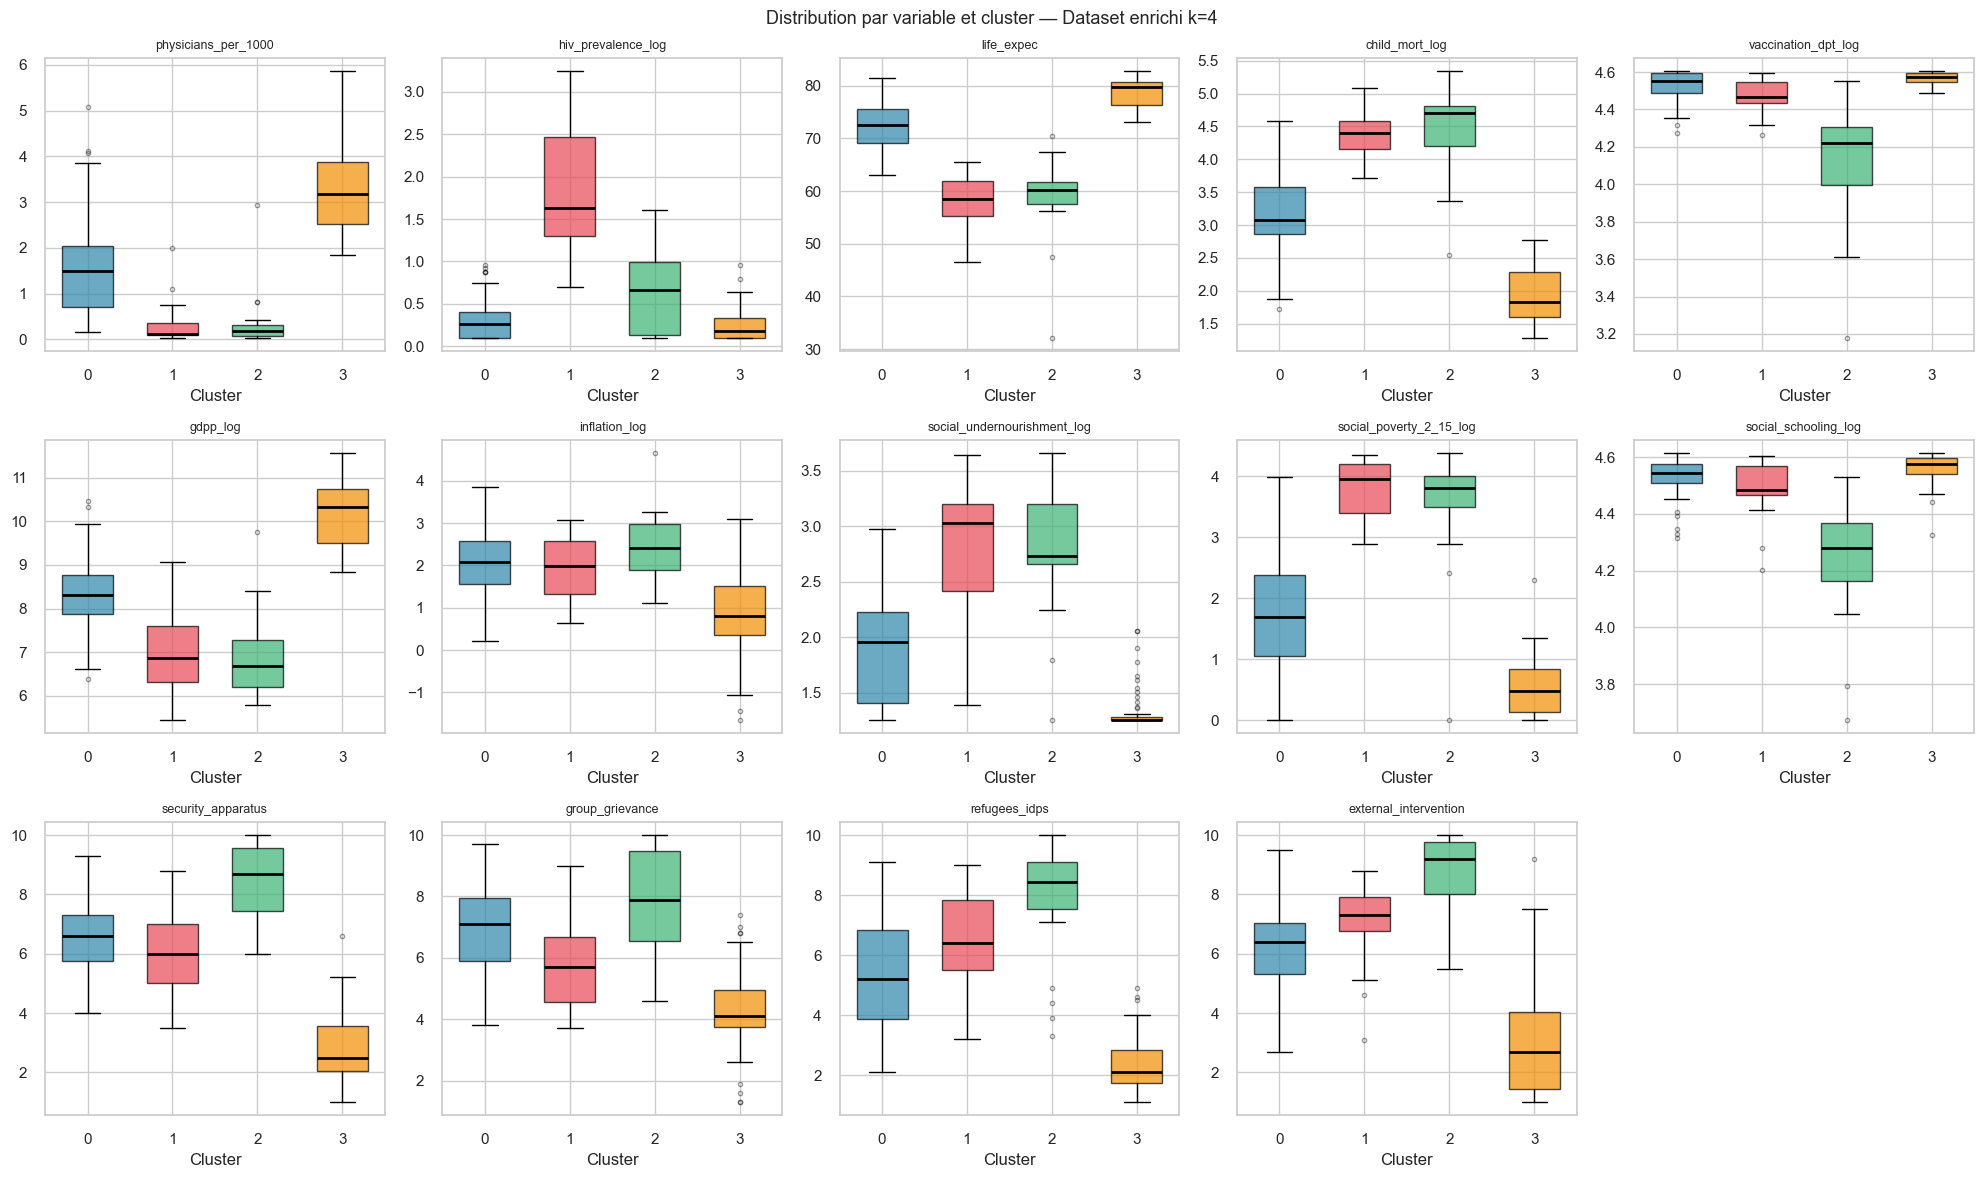

In [446]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_e):
    ax = axes[i]
    for cl in sorted(df_cl_e['cluster'].unique()):
        data = df_cl_e[df_cl_e['cluster'] == cl][col]
        ax.boxplot(data, positions=[cl], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[cl], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_xticks([0, 1, 2, 3])

for j in range(len(num_cols_e), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution par variable et cluster — Dataset enrichi k=4', fontsize=13)
plt.tight_layout(); plt.show()

Le profilage des 4 clusters du dataset enrichi révèle quatre profils humanitaires distincts.

Le cluster à gdpp_log ≈ 10.2 et security_apparatus ≈ 2.8 regroupe les pays développés et stables (≈51 pays) : Europe, Amérique du Nord, Australasie, pays du Golfe. Ce sont les pays que l'ONG ne cible pas.

Le cluster intermédiaire (≈71 pays) présente des indicateurs modérés sur toutes les dimensions : développement en cours, fragilité partielle. Des interventions de soutien structurel (éducation, santé primaire) y sont pertinentes.

Le cluster à hiv_prevalence_log ≈ 1.83 (≈23 pays) identifie la crise VIH d'Afrique subsaharienne : Zimbabwe, Lesotho, Botswana, Kenya, Namibie... La prévalence brute du VIH dans ces pays est structurellement différente de tous les autres groupes. L'intervention requise est sanitaire et programmatique (thérapies antirétrovirales, prévention).

Le cluster à security_apparatus ≈ 8.4 et group_grievance ≈ 7.9 (≈22 pays) identifie les États en situation de conflit ou d'effondrement institutionnel : Afghanistan, République Centrafricaine, Tchad, RDC, Somalie... Ces pays cumulent fragilité institutionnelle et violence armée. L'intervention humanitaire y relève de l'aide d'urgence et de la protection des civils.

In [447]:
for cl in sorted(df_cl_e['cluster'].unique()):
    pays = df_cl_e[df_cl_e['cluster'] == cl]['country'].sort_values().tolist()
    print(f'Cluster {cl} (n={len(pays)}) : {pays[:12]}{"..." if len(pays)>12 else ""}')
    print()

Cluster 0 (n=71) : ['Albania', 'Algeria', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil']...

Cluster 1 (n=23) : ['Benin', 'Botswana', 'Burundi', 'Cameroon', 'Congo', 'Gabon', 'Gambia', 'Ghana', 'Guinea-Bissau', 'Kenya', 'Kiribati', 'Lesotho']...

Cluster 2 (n=22) : ['Afghanistan', 'Angola', 'Burkina Faso', 'Central African Republic', 'Chad', 'Congo, The Democratic Republic of the', "Côte d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Guinea', 'Haiti', 'Iraq']...

Cluster 3 (n=51) : ['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belgium', 'Bulgaria', 'Canada', 'Chile', 'Costa Rica', 'Croatia']...



## 2.9 Carte géographique

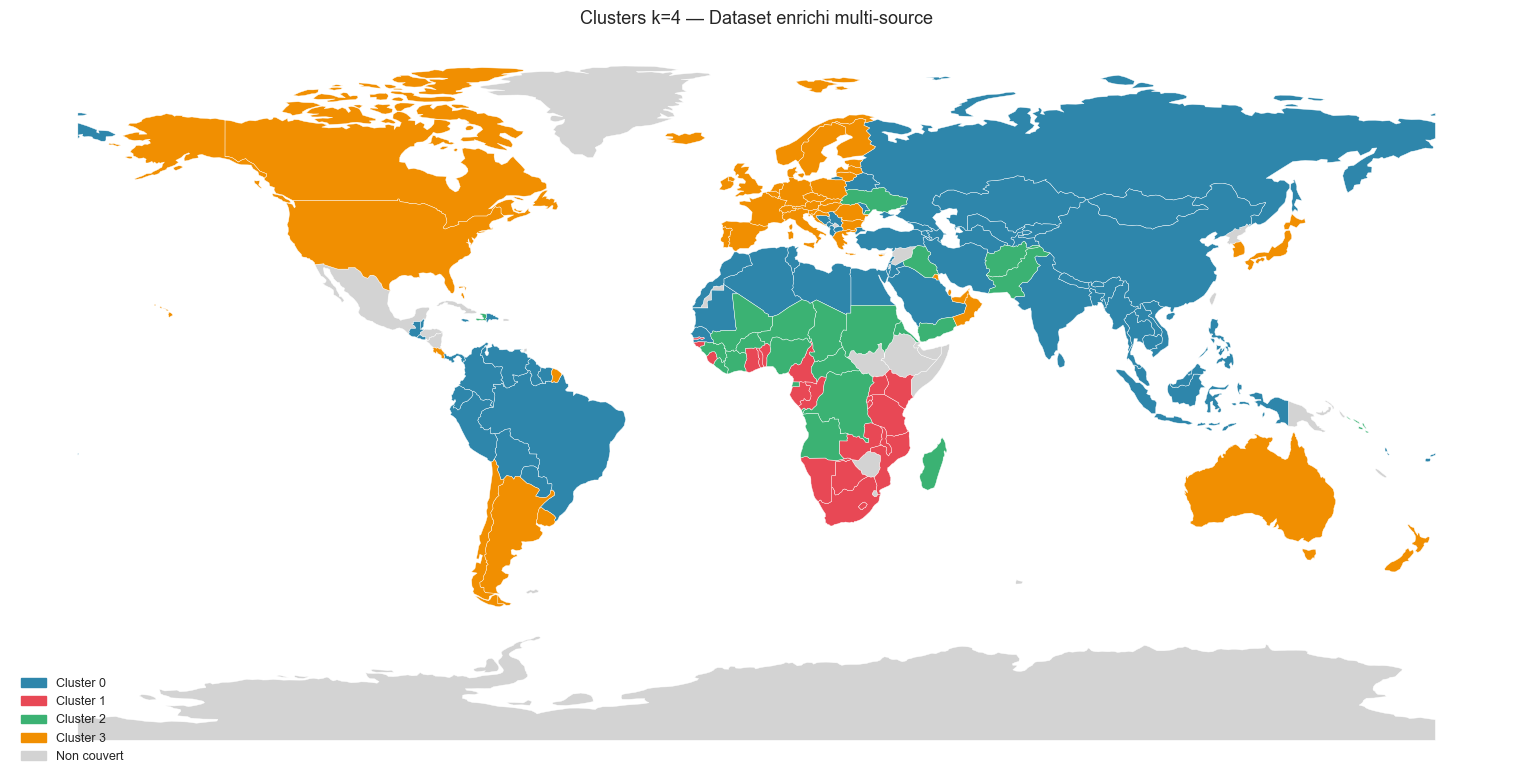

In [448]:
df_map_e = df_cl_e[['country', 'cluster']].copy()
df_map_e['country'] = apply_ne_mapping(df_map_e['country'], dataset='enriched')

world_e = world.merge(df_map_e, left_on='ADMIN', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(16, 8))
world_e[world_e['cluster'].isna()].plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in sorted(df_map_e['cluster'].dropna().unique()):
    world_e[world_e['cluster'] == cl].plot(ax=ax, color=PALETTE[int(cl)],
                                            edgecolor='white', linewidth=0.3)
patches = [mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_E)]
patches.append(mpatches.Patch(color='#D3D3D3', label='Non couvert'))
ax.legend(handles=patches, loc='lower left', fontsize=9)
ax.set_title('Clusters k=4 — Dataset enrichi multi-source', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()

---
# Partie III :Comparaison inter-datasets

In [449]:
metrics_comp = pd.DataFrame({
    'Dataset':         ['Classique (k=3)', 'Enrichi (k=4)'],
    'k':               [K_FINAL_R, K_FINAL_E],
    'Nb variables':    [len(num_cols_r), len(num_cols_e)],
    'Silhouette':      [round(silhouette_score(X_raw, labels_r), 4),
                        round(silhouette_score(X_enrich, labels_e), 4)],
    'CH':              [round(calinski_harabasz_score(X_raw, labels_r), 1),
                        round(calinski_harabasz_score(X_enrich, labels_e), 1)],
    'DB':              [round(davies_bouldin_score(X_raw, labels_r), 4),
                        round(davies_bouldin_score(X_enrich, labels_e), 4)],
    'ARI stabilité':   [round(float(np.mean(aris_r)), 4),
                        round(float(np.mean(aris_e)), 4)],
})
print(metrics_comp.to_string(index=False))

        Dataset  k  Nb variables  Silhouette   CH     DB  ARI stabilité
Classique (k=3)  3             8      0.2338 63.9 1.4153         0.9562
  Enrichi (k=4)  4            14      0.2840 75.6 1.1982         0.9655


Le dataset enrichi k=4 affiche un ARI de stabilité de 0.966, supérieur au classique k=3 (0.956). La silhouette légèrement plus faible s'explique par l'espace de plus grande dimensionnalité (14 variables) : dans un espace euclidien de dimension plus élevée, les distances entre points augmentent et les frontières de cluster deviennent moins nettes métriquement — mais plus informatives humanitairement.

### Matrice de concordance 

Précaution méthodologique : les labels numériques de clusters sont arbitraires. L'ARI inter-datasets mesure la concordance structurelle entre les deux partitions, indépendamment de la numérotation.

In [450]:
dr = pd.DataFrame({'country': df_raw['country'].values, 'label_r': labels_r})
de = pd.DataFrame({'country': df_enrich['country'].values, 'label_e': labels_e})
mg = pd.merge(dr, de, on='country', how='inner')

ari_inter = adjusted_rand_score(mg['label_r'], mg['label_e'])
print(f'ARI inter-datasets : {ari_inter:.4f}')
print(f'Pays alignés : {len(mg)} / 167')
print()

# pd.crosstab produit une matrice (K_r x K_e) sans hypothèse de carrée
ct = pd.crosstab(mg['label_r'], mg['label_e'],
                 rownames=['Cl. classique'], colnames=['Cl. enrichi'])
print('Matrice de concordance (lignes = classique k=3, colonnes = enrichi k=4) :')
print(ct.to_string())

ARI inter-datasets : 0.4762
Pays alignés : 157 / 167

Matrice de concordance (lignes = classique k=3, colonnes = enrichi k=4) :
Cl. enrichi     0   1   2   3
Cl. classique                
0               7   0   0  43
1              52   3   4   8
2               6  18  16   0


### Cartes comparatives

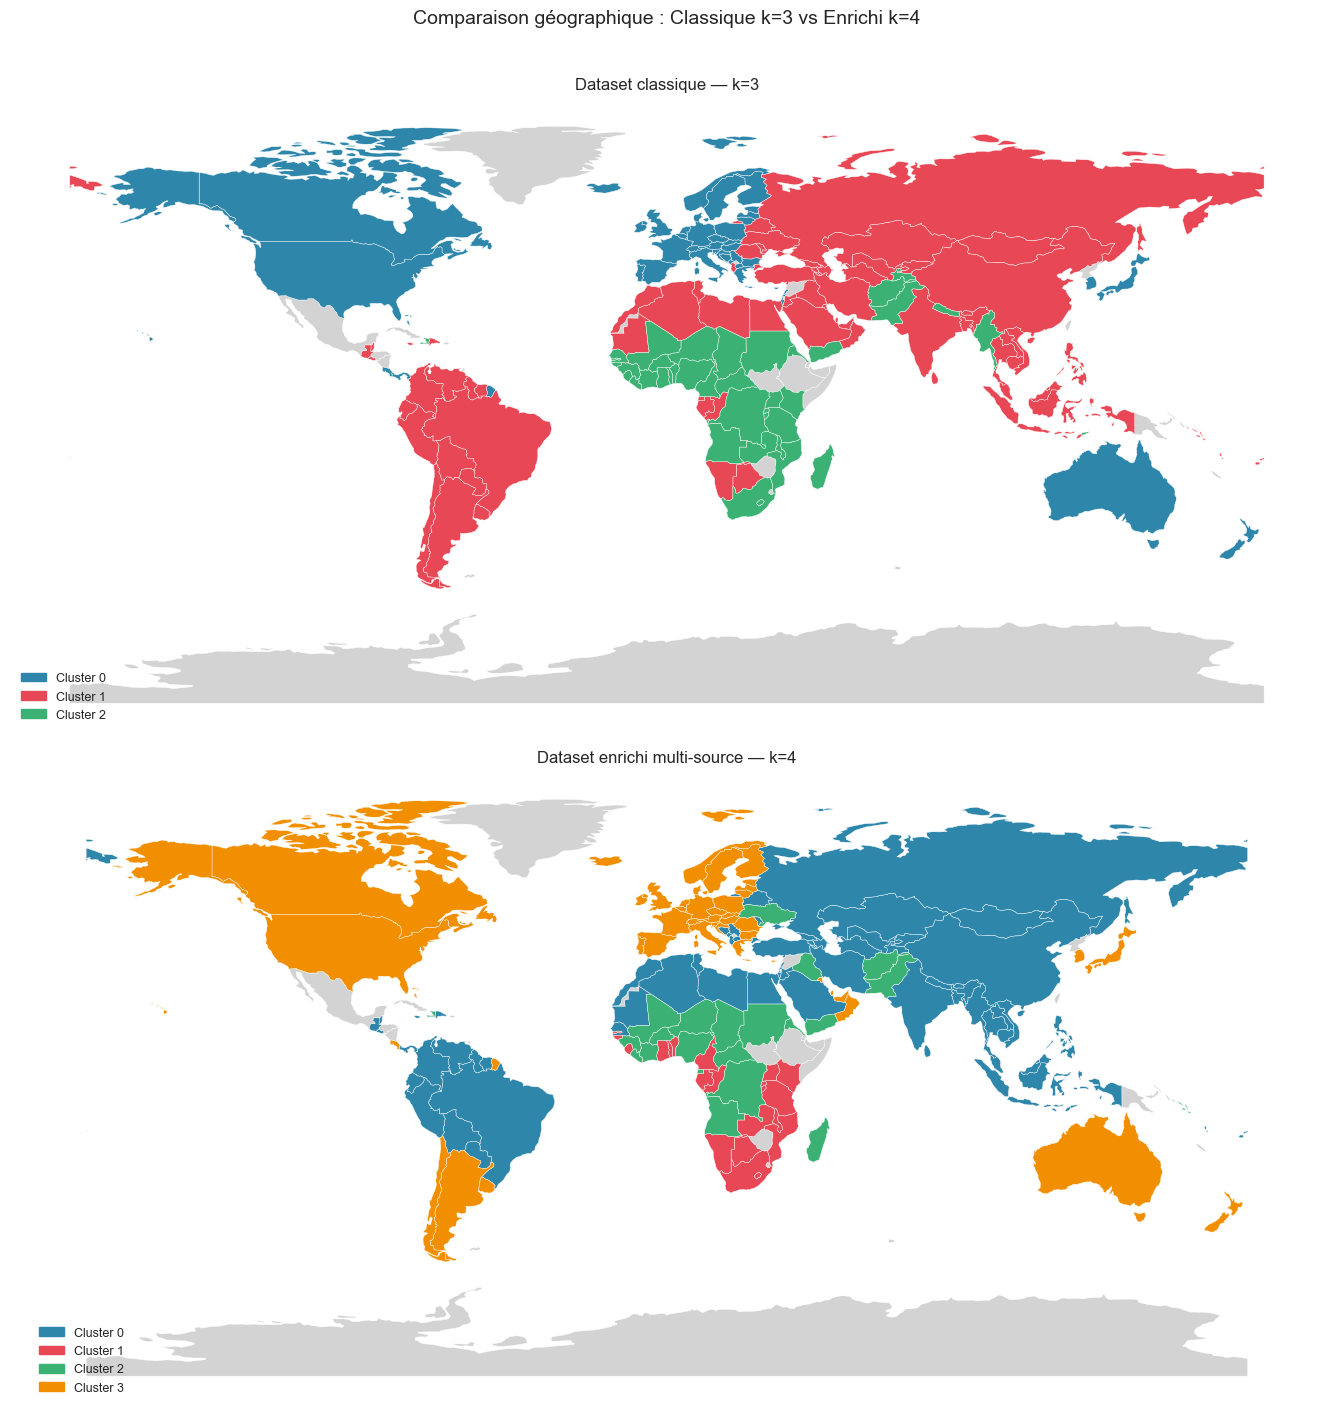

In [451]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Classique
df_mr2 = df_raw[['country']].copy()
df_mr2['cluster'] = labels_r
df_mr2['country'] = apply_ne_mapping(df_mr2['country'], dataset='classic')
world_r2 = world.merge(df_mr2, left_on='ADMIN', right_on='country', how='left')
world_r2[world_r2['cluster'].isna()].plot(ax=axes[0], color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in range(K_FINAL_R):
    world_r2[world_r2['cluster'] == cl].plot(ax=axes[0], color=PALETTE[cl], edgecolor='white', linewidth=0.3)
axes[0].legend(handles=[mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_R)],
               loc='lower left', fontsize=9)
axes[0].set_title('Dataset classique — k=3', fontsize=12); axes[0].axis('off')

# Enrichi
df_me2 = df_enrich[['country']].copy()
df_me2['cluster'] = labels_e
df_me2['country'] = apply_ne_mapping(df_me2['country'], dataset='enriched')
world_e2 = world.merge(df_me2, left_on='ADMIN', right_on='country', how='left')
world_e2[world_e2['cluster'].isna()].plot(ax=axes[1], color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in range(K_FINAL_E):
    world_e2[world_e2['cluster'] == cl].plot(ax=axes[1], color=PALETTE[cl], edgecolor='white', linewidth=0.3)
axes[1].legend(handles=[mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_E)],
               loc='lower left', fontsize=9)
axes[1].set_title('Dataset enrichi multi-source — k=4', fontsize=12); axes[1].axis('off')

plt.suptitle('Comparaison géographique : Classique k=3 vs Enrichi k=4', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
# Partie IV : Export des modèles

Les modèles sont sérialisés avec `joblib`, optimal pour les objets sklearn (compression efficace des arrays numpy internes). Les fichiers de labels et profils sont également exportés en CSV pour usage dans P3 (interprétation) et dans l'application de dashboard.

In [452]:
models_dir = paths.ROOT_DIR / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# Modèles KMeans
joblib.dump(km_r, models_dir / 'kmeans_k3_classique.joblib')
joblib.dump(km_e, models_dir / 'kmeans_k4_enrichi.joblib')

# Labels + profils
df_cl_r.to_csv(models_dir / 'clusters_classique_k3.csv', index=False)
df_cl_e.to_csv(models_dir / 'clusters_enrichi_k4.csv', index=False)

# Scalers (pour prédiction future)
joblib.dump(scaler_r, models_dir / 'scaler_classique.joblib')
joblib.dump(scaler_e, models_dir / 'scaler_enrichi.joblib')

print('Exports réalisés dans models/ :')
for f in sorted(models_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:45s}  {size_kb:6.1f} Ko')

Exports réalisés dans models/ :
  clusters_classique_k3.csv                        19.4 Ko
  clusters_enrichi_k4.csv                          32.5 Ko
  kmeans_k3_classique.joblib                        1.5 Ko
  kmeans_k4_enrichi.joblib                          1.8 Ko
  scaler_classique.joblib                           1.0 Ko
  scaler_enrichi.joblib                             1.2 Ko


# FIN